In [1]:
# Importing Libraries
import pandas as pd
import os
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# =============================
# 1. LOAD DATA
# =============================
df = pd.read_csv(
    r"C:\Users\Shaik Mahammad Irfan\Health_Monitoring_Agent\data\synthetic_health_claims.csv"
)

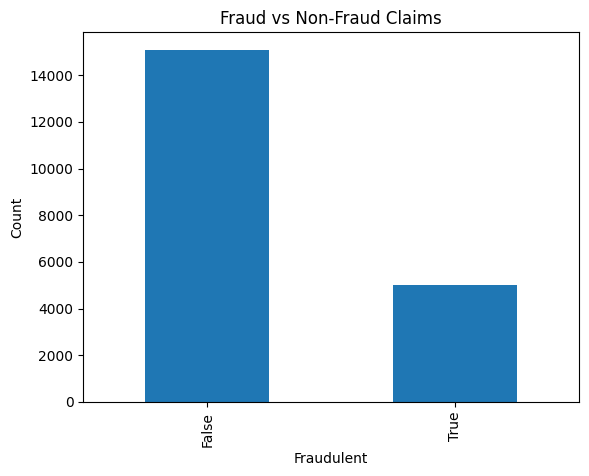

In [3]:
import matplotlib.pyplot as plt

df["Is_Fraudulent"].value_counts().plot(kind="bar")
plt.title("Fraud vs Non-Fraud Claims")
plt.xlabel("Fraudulent")
plt.ylabel("Count")
plt.show()

In [4]:
# =============================
# 2. FEATURE ENGINEERING (VERY IMPORTANT - DO FIRST)
# =============================

df["Claim_Date"] = pd.to_datetime(df["Claim_Date"], dayfirst=True)
df["Service_Date"] = pd.to_datetime(df["Service_Date"], dayfirst=True)
df["Policy_Expiration_Date"] = pd.to_datetime(df["Policy_Expiration_Date"], dayfirst=True)

df["Claim_Delay_Days"] = (df["Claim_Date"] - df["Service_Date"]).dt.days
df["Days_To_Policy_Expiry"] = (df["Policy_Expiration_Date"] - df["Claim_Date"]).dt.days
df["Claim_Month"] = df["Claim_Date"].dt.month
df["Claim_DayOfWeek"] = df["Claim_Date"].dt.dayofweek
df["Claim_to_Age_Ratio"] = df["Claim_Amount"] / (df["Patient_Age"] + 1)
df["High_Claim_Flag"] = (df["Claim_Amount"] > df["Claim_Amount"].quantile(0.9)).astype(int)
df["Frequent_Claim_Flag"] = (df["Number_of_Previous_Claims_Patient"] > 5).astype(int)
df["Claim_Submitted_Late"] = df["Claim_Submitted_Late"].astype(str)
df["Claim_per_Procedure"] = (
    df["Claim_Amount"] /
    (df["Number_of_Procedures"] + 1)
)
df["Provider_Claim_Ratio"] = (
    df["Number_of_Previous_Claims_Provider"] /
    (df["Number_of_Previous_Claims_Patient"] + 1)
)
df["Late_and_HighClaim"] = (
    (df["Claim_Submitted_Late"] == True) &
    (df["High_Claim_Flag"] == 1)
).astype(int)

# Drop raw date columns
df.drop(columns=["Claim_Date", "Service_Date", "Policy_Expiration_Date"], inplace=True)

In [5]:
# =============================
# 3. FEATURE SELECTION
# =============================
selected_features = [
    "Claim_Amount",
    "Patient_Age",
    "Provider_Type",
    "Provider_Specialty",
    "Diagnosis_Code",
    "Procedure_Code",
    "Number_of_Procedures",
    "Admission_Type",
    "Discharge_Type",
    "Service_Type",
    "Length_of_Stay_Days",
    "Deductible_Amount",
    "CoPay_Amount",
    "Number_of_Previous_Claims_Patient",
    "Number_of_Previous_Claims_Provider",
    "Provider_Patient_Distance_Miles",
    "Claim_Submitted_Late",
    "Claim_Delay_Days",
    "Days_To_Policy_Expiry",
    "Claim_Month",
    "Claim_DayOfWeek",
    "Claim_to_Age_Ratio",
    "High_Claim_Flag",
    "Frequent_Claim_Flag"
]
X = df[selected_features]
y = df["Is_Fraudulent"]

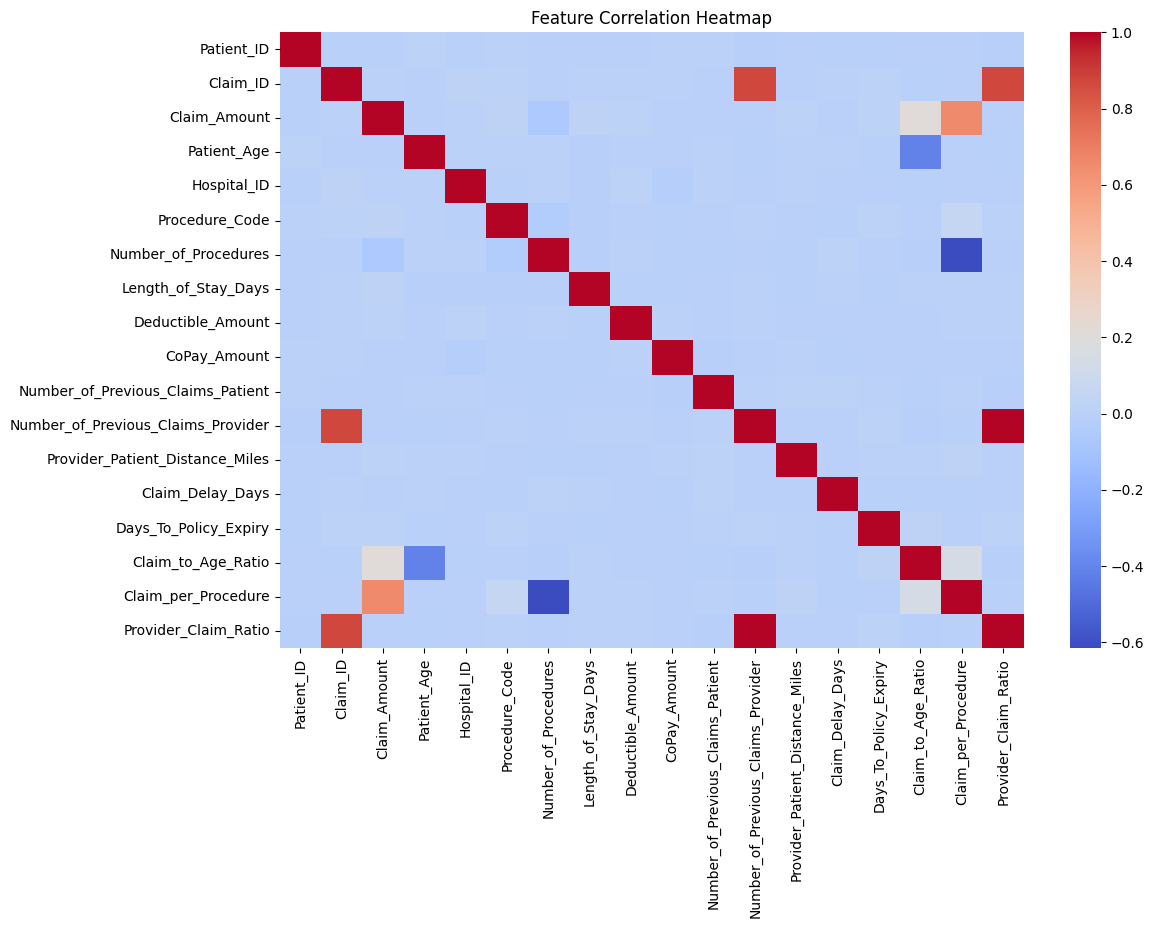

In [6]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.select_dtypes(include=["int64","float64"])
      .corr(),
    cmap="coolwarm",
    annot=False
)

plt.title("Feature Correlation Heatmap")
plt.show()

In [7]:
# =============================
# 4. TRAIN TEST SPLIT
# =============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [8]:
# =============================
# 5. PREPROCESSING PIPELINE
# =============================
cat_cols = [
    "Provider_Type",
    "Provider_Specialty",
    "Diagnosis_Code",
    "Procedure_Code",
    "Admission_Type",
    "Discharge_Type",
    "Service_Type",
    "Claim_Submitted_Late"
]

num_cols = [col for col in X.columns if col not in cat_cols]

num_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_transformer, num_cols),
    ("cat", cat_transformer, cat_cols)
])

In [9]:
# =============================
# 6. MODEL
# =============================
model = ImbPipeline([
    ("preprocess", preprocessor),
    ("smote", SMOTE(sampling_strategy=0.5,random_state=42)),
    ("model", XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        eval_metric="logloss",
        scale_pos_weight=2, 
        random_state=42
    ))
])

In [10]:
if __name__ == "__main__":

    # Create models folder if it doesn't exist
    os.makedirs("models", exist_ok=True)

    # Train model
    model.fit(X_train, y_train)

    # Save model
    joblib.dump(model, "models/fraud_model.pkl")

    print("Model saved successfully!")

    # Evaluate
    probs = model.predict_proba(X_test)[:, 1]
    threshold = 0.50  
    y_pred = (probs >= threshold).astype(int)
    

    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(classification_report(y_test, y_pred))

Model saved successfully!
Accuracy: 0.8400
              precision    recall  f1-score   support

       False       0.92      0.86      0.89      3018
        True       0.65      0.79      0.71      1002

    accuracy                           0.84      4020
   macro avg       0.79      0.82      0.80      4020
weighted avg       0.85      0.84      0.84      4020



In [11]:
# Showing the top features
feature_names = model.named_steps["preprocess"].get_feature_names_out()

importance = model.named_steps["model"].feature_importances_

imp_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values("Importance", ascending=False)

print(imp_df.head(20))

                                       Feature  Importance
20        cat__Provider_Type_Specialist Office    0.109400
2                    num__Number_of_Procedures    0.054896
79                    cat__Discharge_Type_Home    0.041333
8         num__Provider_Patient_Distance_Miles    0.040526
0                            num__Claim_Amount    0.039095
76                  cat__Admission_Type_Urgent    0.038969
16                   cat__Provider_Type_Clinic    0.038941
72                cat__Admission_Type_Elective    0.034897
80   cat__Discharge_Type_Rehab/Skilled Nursing    0.033508
66                   cat__Procedure_Code_99203    0.033122
77  cat__Discharge_Type_Against Medical Advice    0.030639
68                   cat__Procedure_Code_99213    0.029120
21              cat__Provider_Type_Urgent Care    0.028511
82                 cat__Service_Type_Ambulance    0.028093
78                cat__Discharge_Type_Deceased    0.027122
84                 cat__Service_Type_Inpatient    0.0247

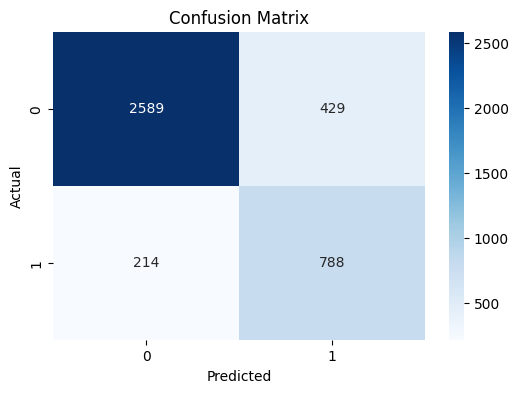

In [12]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

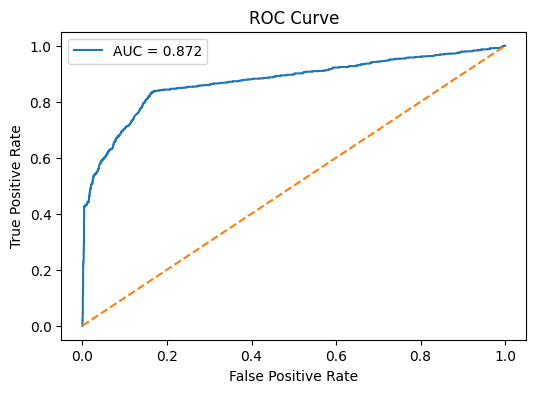

In [13]:
y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()